In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Scripts.pam_generation_uniprot_id import set_up_ecoli_pam
from Scripts.pam_generation import setup_ecoli_pam as set_up_ecoli_pam_curated
from Modules.utils.sector_config_functions import change_translational_sector_with_config_dict


# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations
    
ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')
DIAGNOSTIC_FILES = [os.path.join('Results','2_parametrization', 'diagnostics',
                                 f'pam_parametrizer_diagnostics_{file_nmbr}.xlsx')for file_nmbr in range(1,7)]

Loading PAModelpy modules version 0.0.4.1
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


# 1. Load reference data (proteomics and fluxes)

In [2]:
# load proteome data (Schmidt et al. 2016)
proteome_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df.head()

,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,0.446640,0.491074,0.578723,1.026062,0.859739,0.934963,0.875724,0.581381,0.711635,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,0.594492,0.556592,0.813304,1.230390,1.007687,1.109002,1.035491,0.704953,0.963569,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,0.144782,0.117351,0.436610,0.751106,0.721180,1.038963,2.562241,1.997324,3.032313,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,0.144920,0.172421,0.309267,0.442385,0.400793,0.403734,0.413947,0.368480,0.448950,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,0.062205,0.049618,0.225865,0.807285,0.737951,0.676351,0.563197,0.378829,0.420765,1.045406


In [3]:
# load flux data glucose
flux_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes',
                            engine='openpyxl',
                            index_col=1)
flux_df.head()

,Description,Reaction_position,Rijsewijk_2011,Nanchen_2006_1,Nanchen_2006_2,Nanchen_2006_3,Nanchen_2006_4
Reaction_ID,,,,,,,
EX_glc__D_e,Glucose uptake,2805,8.26,1.670000,2.800000,4.220000,5.650000
BIOMASS_Ec_iML1515_core_75p37M,Growth rate,2712,0.61,0.085000,0.187000,0.286000,0.399000
EX_ac_e_f,Acetate secretion,34,4.89,0.000000,0.000000,0.000000,0.000000
PGI_f,Upper EMP (pgi),102,5.81,1.204014,1.565375,2.653420,3.625868
G6PDH2r_f,Upper PPP (zwf),658,2.29,0.461701,1.263167,1.639352,2.058864


In [4]:
# load exchange rates for different carbon sources by Gerosa et al. (2015) in Ecoli BW25113
flux_csources_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes_Csources',
                            engine='openpyxl',
                            index_col=0)
flux_csources_df.head()

,Reaction identifier,Reversibility,Acetate,Fructose,Galactose,Glucose,Glycerol,Gluconate,Pyruvate,Succinate,Glucose (flux ratio Glc)
Flux (publication),,,,,,,,,,,
Ace_Ex,EX_ac_e_b,NaN,13.584,-3.32866,-1.968939e-08,-6.827019,-0.597000,-5.003982,-11.91391,-3.320974,-0.70717
Fru_Ex,EX_fru_e_b,NaN,0.000,8.32800,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
Gal_Ex,EX_gal_e_b,NaN,0.000,0.00000,1.969000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
Glc_Ex,EX_glc__D_e_b,NaN,0.000,0.00000,0.000000e+00,9.654000,0.000000,0.000000,0.00000,0.000000,1.00000
Gly_Ex,EX_glyc_e_b,NaN,0.000,0.00000,0.000000e+00,0.000000,4.944834,0.000000,0.00000,0.000000,0.00000


# 2. Setup the *Escherichia coli* iML1515 model with new parameters

In [5]:
#setup the model
ecoli_pam_wt = set_up_ecoli_pam(sensitivity=False) # not curation for reference
ecoli_pam_curated = set_up_ecoli_pam_curated(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
    sensitivity = False) # curated for reference
ecoli_pam_new = set_up_ecoli_pam(os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_240730_multi.xlsx'),
                                 sensitivity=False)

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:245: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515



In [6]:
# extract the optimized kcats and do the changes
mutated_kcats = pd.read_excel(PARAMETER_RESULT_FILE, sheet_name='Best_Individuals')
mutated_kcats.groupby('run_id')
for i, row in mutated_kcats.iterrows():
    kcat_dict = {row['rxn_id']:{row['direction']:row['kcat[s-1]']}}
    ecoli_pam_new.change_kcat_value(enzyme_id=row['enzyme_id'], kcats = kcat_dict)

/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1488: UserWarning: The enzyme E0 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')
/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:1488: UserWarning: The enzyme E35 does not exist in the model. The kcat can thus not be changed.
  warnings.warn(f'The enzyme {enzyme_id} does not exist in the model. The kcat can thus not be changed.')


# 3. Check internal flux distribution (glucose as C source)

In [7]:
def remove_suffixes(strings):
    modified_strings = []
    for string in strings:
        if string.endswith('_f') or string.endswith('_b'):
            modified_strings.append(string[:-2])  # Remove last two characters
        else:
            modified_strings.append(string)  # Keep the string unchanged
    return modified_strings

In [35]:
def enzyme_concentration(enz):
    fwd_value = enz.enzyme_variable.forward_variable.primal
    rev_value = enz.enzyme_variable.reverse_variable.primal
    return fwd_value+rev_value

def run_simulations(pamodel, substrate_rates, fluxes_to_save = None, proteins_to_save = None, 
                    transl_sector_config = True) -> list:
    if transl_sector_config: 
        transl_sector_config = {'slope': pamodel.sectors.get_by_id('TranslationalProteinSector').tps_mu[0],
                    'intercept': pamodel.sectors.get_by_id('TranslationalProteinSector').tps_0[0]}

        change_translational_sector_with_config_dict(pamodel, transl_sector_config, 'EX_glc__D_e')
    
    if fluxes_to_save is not None:
        fluxes = pd.DataFrame(columns = ['substrate']+fluxes_to_save)
    if proteins_to_save is not None:
        proteins = pd.DataFrame(columns = ['enzyme_id', 'fraction', 'growth_rate', 'substrate_uptake'])

    for substrate in substrate_rates:
        pamodel.change_reaction_bounds(rxn_id='EX_glc__D_e',
                                       lower_bound=substrate, upper_bound=0)
        print('Running simulations with ', substrate, 'mmol/g_cdw/h of substrate going into the system')
        sol_pam =pamodel.optimize()
        if pamodel.solver.status == 'optimal' and pamodel.objective.value>0:
            if fluxes_to_save is not None:
                solution_flux = [substrate]+ [sol_pam[rxn] if rxn in pamodel.reactions else np.NaN for rxn in fluxes_to_save]
                fluxes.loc[len(fluxes)] = solution_flux
            if proteins_to_save is not None:
                total_conc = 0
                for enzid in proteins_to_save:
                    enzyme = pamodel.enzymes.get_by_id(enzid)
                    conc = enzyme.concentration
                    total_conc += conc
                    proteins.loc[len(proteins)] = [enzid, conc, pamodel.objective.value, substrate]
                
    if proteins_to_save is not None: 
        return proteins
    if fluxes_to_save is not None:
        return fluxes.sort_values('substrate', ascending = False)

In [9]:
def calculate_error_for_reactions(validation_df: pd.DataFrame,
                                   flux_df: pd.DataFrame,
                                  rxns_to_validate: list) -> float:
    # calculate error for different exchange rates
    error = []
    for rxn in rxns_to_validate:
        # only select the rows which are filled with data
        validation_data = validation_df.dropna(axis=0, subset=rxn)
        # if there are no reference data points, continue to the next reaction
        if len(validation_data) == 0:
            continue

        r_squared = calculate_r_squared_for_reaction(rxn, validation_df, 'EX_glc__D_e',
                                                           flux_df)
        error += [r_squared]
    return error

def calculate_r_squared_for_reaction(reaction_id: str, validation_data: pd.DataFrame,
                                     substrate_uptake_id: str,
                                      fluxes: pd.DataFrame) -> float:
    substr_rxn = substrate_uptake_id
    # Take the absolute value of substrate uptake to avoid issues with reaction directionality
    validation_data[substr_rxn] = [round(abs(flux),4) for flux in validation_data[substr_rxn]]
    simulated_data = pd.DataFrame({substr_rxn: [round(abs(flux),4) for flux in fluxes['substrate']],
                                   'simulation': fluxes[reaction_id]})
    ref_data_rxn = pd.merge(validation_data,simulated_data,on=substr_rxn, how='inner')
    # error: squared difference
    ref_data_rxn = ref_data_rxn.assign(error=lambda x: (x[reaction_id] - x['simulation']) ** 2)

    # calculate R^2:
    data_average = np.nanmean(validation_data[reaction_id])
    residual_ss = np.nansum(ref_data_rxn.error)
    total_ss = np.nansum([(data - data_average) ** 2 for data in ref_data_rxn[reaction_id]])
    # calculating r_squared is only feasible of the numerator and the denomenator are both nonzero
    if (residual_ss == 0) | (total_ss == 0):
        r_squared = 0
    else:
        r_squared = 1 - residual_ss / total_ss
    return r_squared

def calculate_difference_simulation_experiment(validation_df, flux_df, rxns_to_validate):
    differences = []
    for rxn in rxns_to_validate:
        # only select the rows which are filled with data
        validation_data = validation_df.dropna(axis=0, subset=rxn)
        # if there are no reference data points, continue to the next reaction
        if len(validation_data) == 0:
            continue
        substr_rxn = 'EX_glc__D_e'
        validation_data[substr_rxn] = [round(abs(flux),4) for flux in validation_data[substr_rxn]]
        simulated_data = pd.DataFrame({substr_rxn: [round(abs(flux),4) for flux in flux_df['substrate']],
                                   'simulation': flux_df[rxn]})
        ref_data_rxn = pd.merge(validation_data,simulated_data,on=substr_rxn, how='inner')
        # error: squared difference
        differences += [row[rxn] - row['simulation'] for i,row in ref_data_rxn.iterrows()]
    return differences

## 3.1 Run the simulations and calculate the errors

In [10]:
# Get the data from the MFA studies of Rijsewijk et al (2011) and Nanchen et al. (2006)
flux_df.index = remove_suffixes(list(flux_df.index))
# flux_df = flux_df.rename(index = {'BIOMASS_Ec_iML1515_WT_75p37M':'BIOMASS_Ecoli_core_w_GAM'})

flux_df_data = flux_df.drop(['Description', 'Reaction_position'], axis =1)


fluxes_to_save = None
flux_information = {}
validation_df = pd.DataFrame(columns = list(flux_df_data.index))
studies = []
substrate_uptake = []
for study, fluxes in flux_df_data.items():
    studies += [study]
    substrate_uptake += [-fluxes.loc['EX_glc__D_e']]
    flux_information[study] = fluxes.to_dict()
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)
    
    #store the names of the fluxes to save
    if fluxes_to_save is None:
        fluxes_to_save = list(fluxes.index)


In [11]:
# for each study, run simulations
fluxes_curated = run_simulations(ecoli_pam_curated, substrate_uptake, fluxes_to_save, transl_sector_config = False)
print('\n')
fluxes_wt = run_simulations(ecoli_pam_wt, substrate_uptake, fluxes_to_save)
print('\n')
fluxes_new = run_simulations(ecoli_pam_new, substrate_uptake, fluxes_to_save)

Running simulations with  -8.26 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1.67 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2.8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4.22 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5.65 mmol/g_cdw/h of substrate going into the system


Running simulations with  -8.26 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1.67 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2.8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4.22 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5.65 mmol/g_cdw/h of substrate going into the system


Running simulations with  -8.26 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1.67 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2.8 mmol/g_

In [12]:
#calculate R^2 value between simulations and experiments
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


error_new = calculate_error_for_reactions(validation_df,
                                                 fluxes_new,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with the optimized parameters: ', np.nanmean(error_new))



R^2 values for the model with published parameter set : -0.7797595752467897
R^2 values for the model with parameters from GotEnzymes:  -2.439047951314783
R^2 values for the model with the optimized parameters:  -0.9181933323143191


## 3.2 Visualize the simulation results for the different models

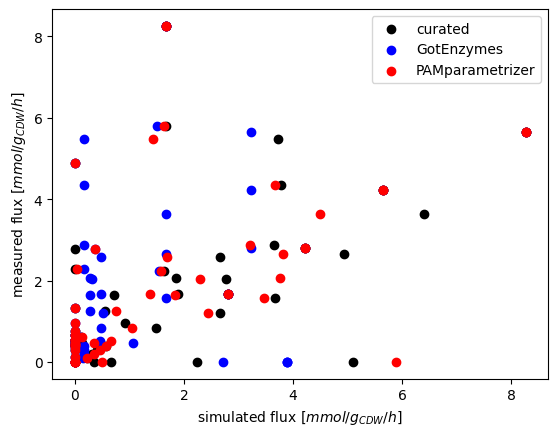

In [13]:
#scatterplot
fig, ax = plt.subplots()

curated = []
wt = []
new = []
validation = []
for i in range(len(fluxes_curated)):
    curated += [abs(f) for f in fluxes_curated.iloc[i].to_list()]
    wt += [abs(f) for f in fluxes_wt.iloc[i].to_list()]
    new += [abs(f) for f in fluxes_new.iloc[i].to_list()]
    validation += [validation_df.iloc[i,0]]+validation_df.iloc[i].to_list()
    
    
plt.scatter(curated, validation, label = 'curated', color = 'black')
plt.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
plt.scatter(new, validation, label = 'PAMparametrizer', color = 'red')

plt.xlabel('simulated flux [$mmol/g_{CDW}/h$]')
plt.ylabel('measured flux [$mmol/g_{CDW}/h$]')
plt.legend()
plt.show()

/tmp/ipykernel_25813/3155777760.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)


Text(0, 0.5, 'Difference exp-sim')

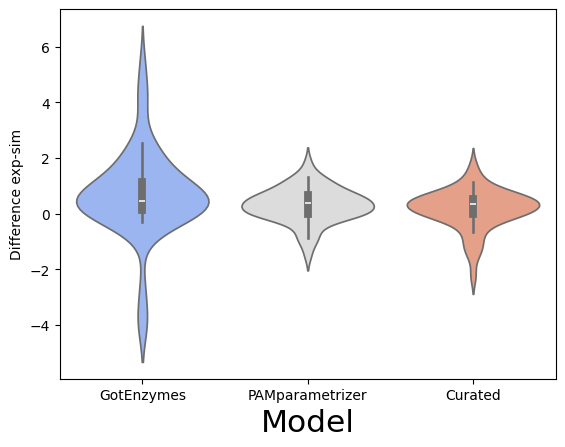

In [14]:
fontsize = 15
#violinplot
models = ['GotEnzymes','PAMparametrizer','Curated']
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))

# Combine data into a DataFrame
all_differences = pd.DataFrame()

for model, sub_df in zip(models, [fluxes_wt, fluxes_new, fluxes_curated]):
    differences = calculate_difference_simulation_experiment(validation_df, sub_df, fluxes_to_save[1:])
    
    # Create a DataFrame for each model with the model name and differences
    temp_df = pd.DataFrame({'Model': model, 'Difference': differences})
    
    # Append to the main DataFrame
    all_differences = pd.concat([all_differences, temp_df])

# Create violinplot
fig, ax = plt.subplots()
sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)

# Set labels and title
ax.set_xlabel('Model', fontsize=fontsize*1.5)
ax.set_ylabel('Difference exp-sim')

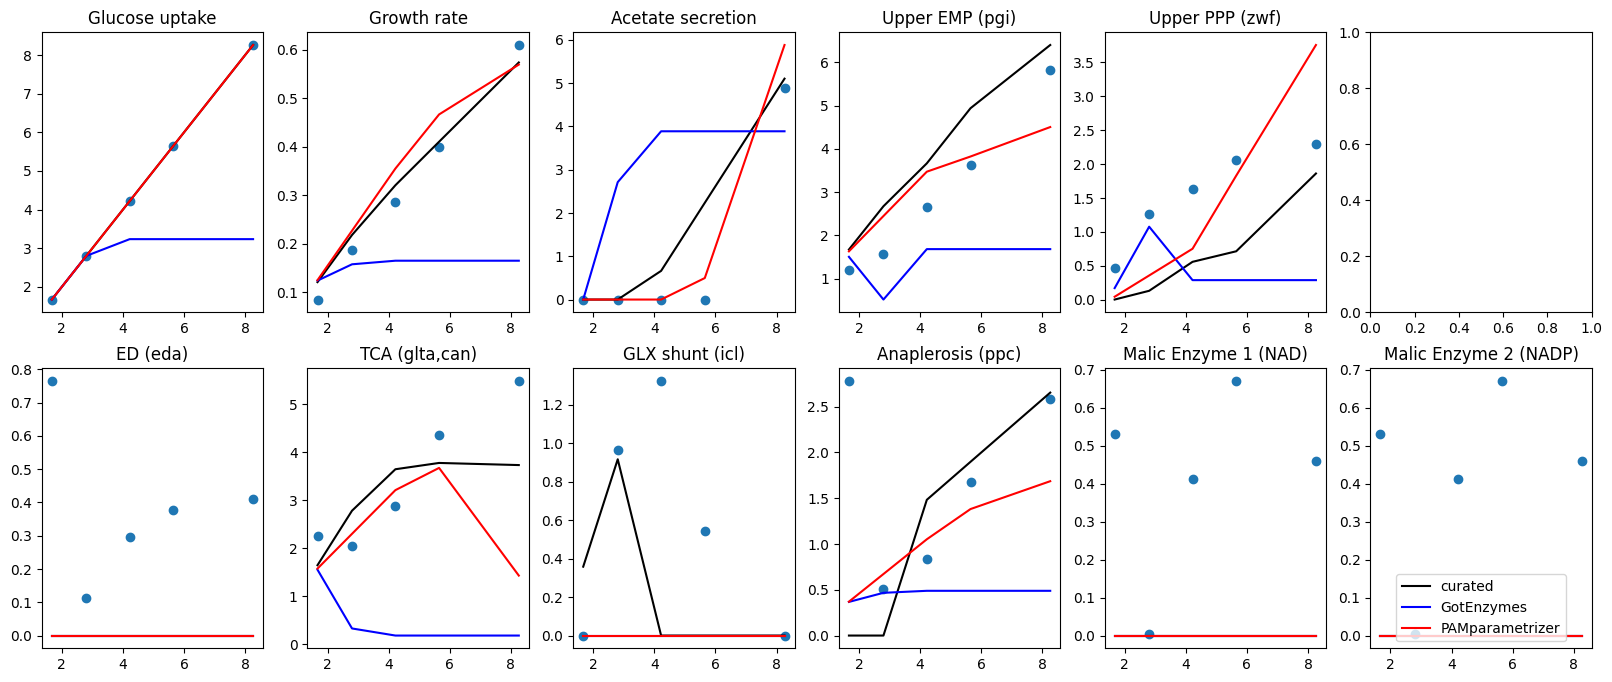

In [15]:
# visualize per flux
fig, axs = plt.subplots(ncols = 6, nrows = 2, figsize = [20,8])

# upper_fig_reactions = [rxn for rxn in fluxes_to_save[:5] if rxn != 'EDA'] #EDA is not in core model
# lower_fig_reactions = [rxn for rxn in fluxes_to_save[5:] if rxn != 'EDA']
upper_fig_reactions = [rxn for rxn in fluxes_to_save[:5]] #EDA is not in core model
lower_fig_reactions = [rxn for rxn in fluxes_to_save[5:]]
substrate_rates = [abs(f) for f in fluxes_curated['substrate']]

for i, rxn in enumerate(upper_fig_reactions):
    validation = validation_df[rxn]
    axs[0,i].scatter(validation_df['EX_glc__D_e'], validation_df[rxn])
    axs[0,i].plot(substrate_rates, [abs(f) for f in fluxes_curated[rxn]], label = 'curated', color = 'black')
    axs[0,i].plot(substrate_rates, [abs(f) for f in fluxes_wt[rxn]],label = 'GotEnzymes', color = 'blue')
    axs[0,i].plot(substrate_rates, [abs(f) for f in fluxes_new[rxn]], label = 'PAMparametrizer', color = 'red')
    axs[0,i].set_title(flux_df.Description.loc[rxn])

for i, rxn in enumerate(lower_fig_reactions):
    axs[1,i].scatter(substrate_rates, validation_df[rxn])
    axs[1,i].plot(substrate_rates, [abs(f) for f in fluxes_curated[rxn]], label = 'curated', color = 'black')
    axs[1,i].plot(substrate_rates, [abs(f) for f in fluxes_wt[rxn]],label = 'GotEnzymes', color = 'blue')
    axs[1,i].plot(substrate_rates, [abs(f) for f in fluxes_new[rxn]], label = 'PAMparametrizer', color = 'red')
    axs[1,i].set_title(flux_df.Description.loc[rxn])


    
plt.legend(loc = 'lower center')

plt.show()

# 4. Check protein distribution (glucose as C source)

## 4.1 Load the reference data from Schmidt et al (2011) and normalize the values

In [16]:
proteome_glc = proteome_df[['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35']] #unit: fg/cell
proteome_glc.columns = ['Batch', 'mu_5', 'mu_35']
proteome_glc

,Batch,mu_5,mu_35
Bnumber,,,
b3988,0.715349,1.230766,1.004203
b3987,0.989135,1.310899,1.096833
b0118,1.178283,2.440666,3.143073
b2557,0.576304,0.536179,0.405983
b3212,0.774653,0.629009,0.530940
...,...,...,...
NaN,0.000167,0.000151,0.000068
NaN,0.000084,0.000644,0.000241
NaN,0.002472,0.000652,0.000320


In [17]:
# match the gene ids to the associated enzymes
gene_enzyme_mapper_df = pd.read_excel(os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_240730_multi.xlsx'),
                                     sheet_name = 'ActiveEnzymes')[['rxn_id', 'gene', 'uniprot_id']]

to_delete = []
for i, row in gene_enzyme_mapper_df.iterrows():
    if not isinstance(row.uniprot_id, str) and row.rxn_id in ecoli_pam_wt.reactions and row.gene!='s0001':
        enzyme_id = ecoli_pam_wt.get_enzymes_with_reaction_id(row.rxn_id)[0]
        gene_enzyme_mapper_df.loc[i, 'uniprot_id'] = enzyme_id
        
#only those entries which are in the model are useful
gene_enzyme_mapper_df = gene_enzyme_mapper_df.drop(index = to_delete)

gene_enzyme_mapper_df 

,rxn_id,gene,uniprot_id
0,CYTDK2,b2066,P0A8F4
1,XPPT,b0238,P0A9M5
2,HXPRT,b0238,P0A9M5
3,HXPRT,b0125,P0A9M2
4,NDPK5,b0474,P69441
...,...,...,...
4114,PCNO,b3253,P26646
4115,CYSTA,b0928,P00509
4116,ACOAD1f,b0221,Q47146
4117,QUINDH,b1692,P0A6D5


In [18]:
#filter the proteomics dataset to only have those genes which are in the model
genes_in_model = [g.id for g in ecoli_pam_wt.genes]
genes_to_include = []
for gene, protein in proteome_glc.iterrows():
    if gene in genes_in_model: 
        genes_to_include += [gene]

proteome_glc_in_model = proteome_glc.loc[genes_to_include]

In [19]:
# match to the enzyme ids
proteome_glc_enz = proteome_glc_in_model.reset_index().merge(gene_enzyme_mapper_df, how = 'inner',
                                                      left_on = 'Bnumber', right_on = 'gene')
proteome_glc_enz = proteome_glc_enz.drop_duplicates(['rxn_id', 'Bnumber', 'uniprot_id'])
proteome_glc_enz

,Bnumber,Batch,mu_5,mu_35,rxn_id,gene,uniprot_id
0,b0118,1.178283,2.440666,3.143073e+00,ACONTb,b0118,P36683
1,b0118,1.178283,2.440666,3.143073e+00,MICITDr,b0118,P36683
2,b0118,1.178283,2.440666,3.143073e+00,ACONTa,b0118,P36683
6,b2557,0.576304,0.536179,4.059834e-01,PRFGS,b2557,P15254
7,b3212,0.774653,0.629009,5.309396e-01,GLUDy,b3212,P09831
...,...,...,...,...,...,...,...
3047,b2251,0.000566,0.000482,8.849426e-05,NTPP3,b2251,P52006
3048,b2251,0.000566,0.000482,8.849426e-05,NTPP7,b2251,P52006
3049,b2251,0.000566,0.000482,8.849426e-05,DUTPDP,b2251,P52006
3050,b1813,0.000341,0.000379,3.274671e-04,HPYRP,b1813,P43337


In [20]:
# normalize each experiment, resulting values are in protein fractions
proteome_glc_normalized = proteome_glc_enz.copy()
#make sure gene duplicates are ignored in the normalization
proteome_glc_per_gene = proteome_glc_enz.drop_duplicates(subset = 'Bnumber')
for col in proteome_glc_in_model.columns:
    proteome_glc_normalized[col] = proteome_glc_enz[col].div(proteome_glc_per_gene[col].sum())
proteome_glc_normalized

,Bnumber,Batch,mu_5,mu_35,rxn_id,gene,uniprot_id
0,b0118,9.739298e-03,1.920261e-02,2.624984e-02,ACONTb,b0118,P36683
1,b0118,9.739298e-03,1.920261e-02,2.624984e-02,MICITDr,b0118,P36683
2,b0118,9.739298e-03,1.920261e-02,2.624984e-02,ACONTa,b0118,P36683
6,b2557,4.763537e-03,4.218533e-03,3.390630e-03,PRFGS,b2557,P15254
7,b3212,6.403027e-03,4.948904e-03,4.434220e-03,GLUDy,b3212,P09831
...,...,...,...,...,...,...,...
3047,b2251,4.676560e-06,3.792696e-06,7.390727e-07,NTPP3,b2251,P52006
3048,b2251,4.676560e-06,3.792696e-06,7.390727e-07,NTPP7,b2251,P52006
3049,b2251,4.676560e-06,3.792696e-06,7.390727e-07,DUTPDP,b2251,P52006
3050,b1813,2.818197e-06,2.984204e-06,2.734890e-06,HPYRP,b1813,P43337


In [21]:
proteome_glc_long = pd.melt(proteome_glc_normalized, value_vars = ['Batch', 'mu_5', 'mu_35'], 
                            id_vars = ['Bnumber', 'rxn_id', 'uniprot_id'],
                           var_name = 'experiment', value_name = 'fraction')
proteome_glc_long

,Bnumber,rxn_id,uniprot_id,experiment,fraction
0,b0118,ACONTb,P36683,Batch,9.739298e-03
1,b0118,MICITDr,P36683,Batch,9.739298e-03
2,b0118,ACONTa,P36683,Batch,9.739298e-03
3,b2557,PRFGS,P15254,Batch,4.763537e-03
4,b3212,GLUDy,P09831,Batch,6.403027e-03
...,...,...,...,...,...
7084,b2251,NTPP3,P52006,mu_35,7.390727e-07
7085,b2251,NTPP7,P52006,mu_35,7.390727e-07
7086,b2251,DUTPDP,P52006,mu_35,7.390727e-07
7087,b1813,HPYRP,P43337,mu_35,2.734890e-06


## 4.2 Run simulations and normalize the results

In [22]:
def enzyme_concentration(enz):
    fwd_value = enz.enzyme_variable.forward_variable.primal
    rev_value = enz.enzyme_variable.reverse_variable.primal
    return fwd_value+rev_value


def run_simulations_fixed_mu(pamodel, growth_rates, proteins_to_save) -> list:
    proteins = pd.DataFrame(columns = ['uniprot_id', 'fraction', 'growth_rate', 'substrate_uptake'])
    #change_objective
    pamodel.objective = 'EX_glc__D_e'
    pamodel.objective.direction = 'min'
    
    for mu in growth_rates:
        pamodel.change_reaction_bounds(rxn_id=pamodel.BIOMASS_REACTION,
                                       lower_bound=mu, upper_bound=mu)
        print('Running simulations with to get a growth rate of', mu, 'h-1')
        sol_pam =pamodel.optimize()
        print(pamodel.solver.status)
        if pamodel.solver.status == 'optimal' and pamodel.objective.value<0:
            total_conc = 0
            for enzid in proteins_to_save:
                enzyme = pamodel.enzymes.get_by_id(enzid)
                conc = enzyme_concentration(enzyme)
                total_conc += conc
                proteins.loc[len(proteins)] = [enzid, conc, mu, pamodel.objective.value]

                
    pamodel.objective.direction = 'max'
    pamodel.objective = pamodel.BIOMASS_REACTION
    return proteins

In [23]:
#setup the core model again to avoid conflicts in memory
ecoli_pam_wt = ecoli_pam_wt.copy(copy_with_pickle = True)
ecoli_pam_curated = ecoli_pam_curated.copy(copy_with_pickle = True) # curated for reference
ecoli_pam_new = ecoli_pam_new.copy(copy_with_pickle = True)

In [36]:
# run the ecoli model and save the enzyme concentrations
proteins_to_save = [enz.id for enz in ecoli_pam_curated.enzyme_variables]
proteins_curated = run_simulations(ecoli_pam_curated, [-10, -4.5, -6],proteins_to_save = proteins_to_save)
print('\n')
proteins_to_save_uniprot = [enz.id for enz in ecoli_pam_wt.enzyme_variables if enz._model is not None]
proteins_wt = run_simulations(ecoli_pam_wt, [-10, -4.5, -6],proteins_to_save = proteins_to_save_uniprot)
print('\n')
proteins_new = run_simulations(ecoli_pam_new, [-10, -4.5, -6],proteins_to_save = proteins_to_save_uniprot)

Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4.5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system


Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4.5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system


Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4.5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system


In [45]:
# normalize the enzyme concentrations
def parse_protein_df(df):
    substrate2method = {-10:'Batch' , -6:'mu_5', -4.5:'mu_35'}
    df['method'] = df.apply(lambda x: substrate2method[x['substrate_uptake']], axis =1)
    # Calculate sum of fraction grouped by substrate_uptake
    sum_by_substrate = df.groupby('substrate_uptake')['fraction'].transform('sum')
    # Divide fraction values by the sum
    df['fraction'] = df['fraction'] / sum_by_substrate
    return df
    

#pivot to long format (one row per enzyme) different df with metadata for substrate and mu
proteins_curated_long = parse_protein_df(proteins_curated)
proteins_wt_long = parse_protein_df(proteins_wt)
proteins_new_long = parse_protein_df(proteins_new)

proteome_simulated = pd.merge(proteins_new_long[['method', 'enzyme_id', 'fraction']], 
                               proteins_wt_long[['method', 'enzyme_id', 'fraction']], 
                              on = ['method', 'enzyme_id'], how = 'outer', copy = False,
                             suffixes=('_new', '_wt'))
# proteome_simulated = pd.merge(proteome_simulated, 
#                               proteins_new_long[['method', 'uniprot_id', 'fraction']], 
#                               on = ['method', 'uniprot_id'], how = 'outer', copy = False,
#                              suffixes = ('','_new'))
total_proteome_df = pd.merge(proteome_simulated, proteome_glc_long,
                            left_on = ['method', 'enzyme_id'], right_on = ['experiment', 'uniprot_id'],
                            how = 'right', suffixes = ('_new', '_exp'))
total_proteome_df

,method,enzyme_id,fraction_new,fraction_wt,Bnumber,rxn_id,uniprot_id,experiment,fraction
0,Batch,P36683,0.002695,0.000000,b0118,ACONTb,P36683,Batch,9.739298e-03
1,Batch,P36683,0.002695,0.000000,b0118,MICITDr,P36683,Batch,9.739298e-03
2,Batch,P36683,0.002695,0.000000,b0118,ACONTa,P36683,Batch,9.739298e-03
3,Batch,P15254,0.000015,0.000590,b2557,PRFGS,P15254,Batch,4.763537e-03
4,NaN,NaN,NaN,NaN,b3212,GLUDy,P09831,Batch,6.403027e-03
...,...,...,...,...,...,...,...,...,...
7084,mu_35,P52006,0.000020,0.000034,b2251,NTPP3,P52006,mu_35,7.390727e-07
7085,mu_35,P52006,0.000020,0.000034,b2251,NTPP7,P52006,mu_35,7.390727e-07
7086,mu_35,P52006,0.000020,0.000034,b2251,DUTPDP,P52006,mu_35,7.390727e-07
7087,mu_35,P43337,0.000000,0.000000,b1813,HPYRP,P43337,mu_35,2.734890e-06


## 4.3 Calculate the R^2 value for the predicted protein concentrations

## 4.4 Compare individual protein concentrations

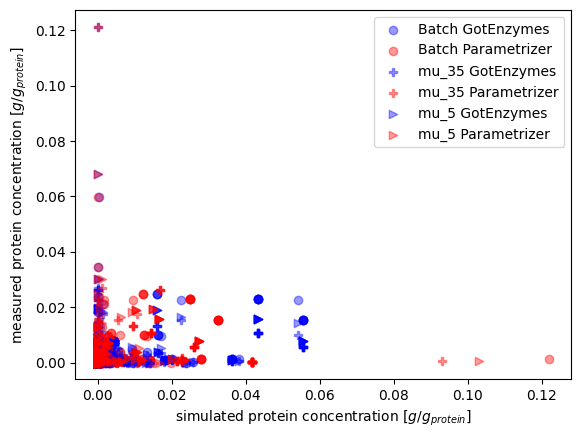

In [46]:
fig, ax = plt.subplots()
grouped = total_proteome_df.groupby('method')
markers = {'mu_5': '>', 'mu_35':'P', 'Batch':'o'}

for group, df in grouped:
    ax.scatter(df['fraction_wt'], df['fraction'],
            c='blue', marker = markers[group], alpha = 0.4, label = group + ' GotEnzymes')
    ax.scatter(df['fraction_new'], df['fraction'],
            c= 'red', marker = markers[group], alpha = 0.4, label = group + ' Parametrizer')

plt.xlabel('simulated protein concentration [$g/g_{protein}$]')
plt.ylabel('measured protein concentration [$g/g_{protein}$]')
plt.legend()
plt.show()

{'PAMparametrizer': (0.6672529243333334, 0.7791764569999999, 0.992959213), 'GotEnzymes': (0.968203399, 0.7208441, 0.6122929913333334)}


/tmp/ipykernel_25813/3074673535.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)
/tmp/ipykernel_25813/3074673535.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)
/tmp/ipykernel_25813/3074673535.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)


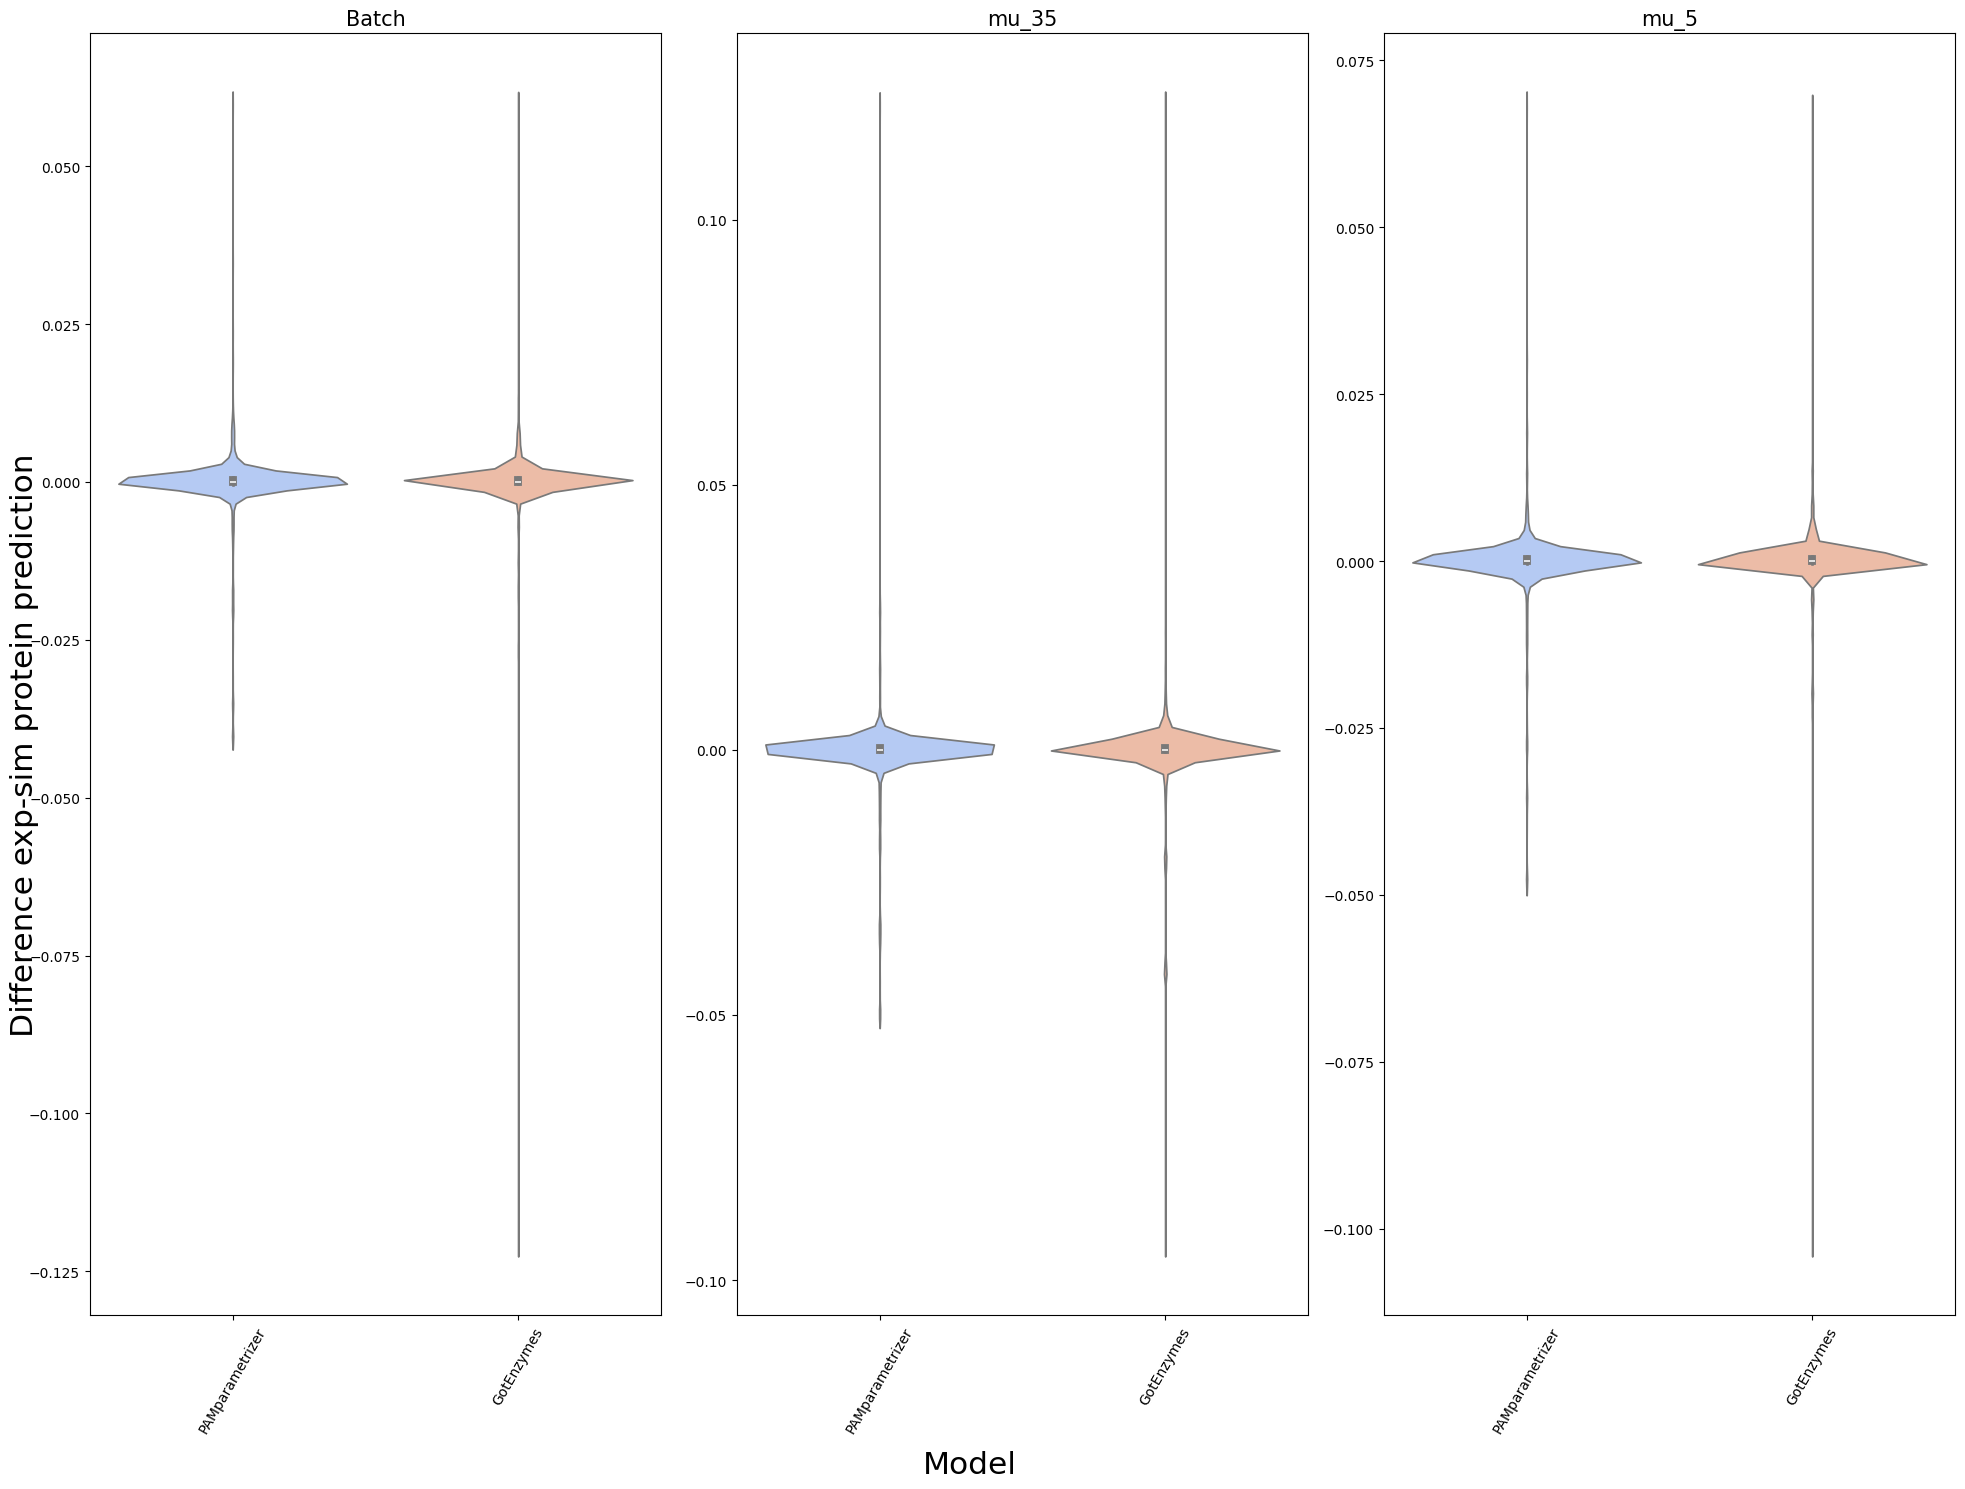

In [67]:
fontsize = 15
#violinplot
models = ['PAMparametrizer', 'GotEnzymes']
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))

print(cmap)

fig, axs = plt.subplots(ncols = 3, figsize=(20,15))
i=0

for method, df in total_proteome_df.groupby('method'):
    # Combine data into a DataFrame
    all_differences = pd.DataFrame()
    ax = axs[i]
    i+=1
    for model, column in zip(models, ['fraction_wt', 'fraction_new']):
#         df = df.dropna(subset = column, axis=1)
        differences = df.fraction - df[column]
    
        # Create a DataFrame for each model with the model name and differences
        temp_df = pd.DataFrame({'Model': model, 'Difference': differences})

        all_differences = pd.concat([all_differences, temp_df])

    # Create violinplot
    sns.violinplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap)
    ax.set_title(method, fontsize = fontsize)
    ax.tick_params(axis='x', labelrotation=60)
    ax.set_xlabel('')
    ax.set_ylabel('')


# Set labels and title
fig.supxlabel('Model', fontsize=fontsize*1.5)
fig.supylabel('Difference exp-sim protein prediction', fontsize=fontsize*1.5)

plt.tight_layout()

## 4.5 Compare fractional protein distribution over the different metabolic pathways (COG)

In [68]:
# map to COGs
total_proteome_df_cog = total_proteome_df.merge(proteome_df_cog[['COG Name']], left_on = 'Bnumber', right_index=True)

In [70]:
cog_data_groups = total_proteome_df_cog.groupby(['experiment', 'COG Name'])
cog_data_summed = cog_data_groups[['fraction_wt', 'fraction_new', 'fraction']].sum()
cog_data_summed

fraction_wt  \
experiment COG Name                                                           
Batch      Amino acid transport and metabolism                 7.922071e-01   
           Carbohydrate transport and metabolism               4.059534e-01   
           Cell cycle control, cell division, chromosome p...  1.029009e-05   
           Cell wall/membrane/envelope biogenesis              1.016358e-02   
           Coenzyme transport and metabolism                   7.289691e-02   
           Defense mechanisms                                  6.683667e-03   
           Energy production and conversion                    2.755485e-02   
           Function unknown                                    5.904150e-07   
           General function prediction only                    7.564655e-03   
           Inorganic ion transport and metabolism              1.653699e-02   
           Lipid transport and metabolism                      2.617053e-01   
           Nucleotide transport and metabolism                 1.397566e-01   
           Posttranslational modification, protein turnove...  0.000000e+00   
           Replication, recombination and repair               6.163636e-07   
           Secondary metabolites biosynthesis, transport a...  0.000000e+00   
           Signal transduction mechanisms                      1.473091e-06   
           Transcription                                       0.000000e+00   
           Translation, ribosomal structure and biogenesis     5.961525e-06   
mu_35      Amino acid transport and metabolism                 7.922071e-01   
           Carbohydrate transport and metabolism               4.059534e-01   
           Cell cycle control, cell division, chromosome p...  1.029009e-05   
           Cell wall/membrane/envelope biogenesis              1.016358e-02   
           Coenzyme transport and metabolism                   7.289691e-02   
           Defense mechanisms                                  6.683667e-03   
           Energy production and conversion                    2.755485e-02   
           Function unknown                                    5.904150e-07   
           General function prediction only                    7.564655e-03   
           Inorganic ion transport and metabolism              1.653699e-02   
           Lipid transport and metabolism                      2.617053e-01   
           Nucleotide transport and metabolism                 1.397566e-01   
           Posttranslational modification, protein turnove...  0.000000e+00   
           Replication, recombination and repair               6.163636e-07   
           Secondary metabolites biosynthesis, transport a...  0.000000e+00   
           Signal transduction mechanisms                      1.473091e-06   
           Transcription                                       0.000000e+00   
           Translation, ribosomal structure and biogenesis     5.961525e-06   
mu_5       Amino acid transport and metabolism                 7.922071e-01   
           Carbohydrate transport and metabolism               4.059534e-01   
           Cell cycle control, cell division, chromosome p...  1.029009e-05   
           Cell wall/membrane/envelope biogenesis              1.016358e-02   
           Coenzyme transport and metabolism                   7.289691e-02   
           Defense mechanisms                                  6.683667e-03   
           Energy production and conversion                    2.755485e-02   
           Function unknown                                    5.904150e-07   
           General function prediction only                    7.564655e-03   
           Inorganic ion transport and metabolism              1.653699e-02   
           Lipid transport and metabolism                      2.617053e-01   
           Nucleotide transport and metabolism                 1.397566e-01   
           Posttranslational modification, protein turnove...  0.000000e+00   
           Replication, recombinati